In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

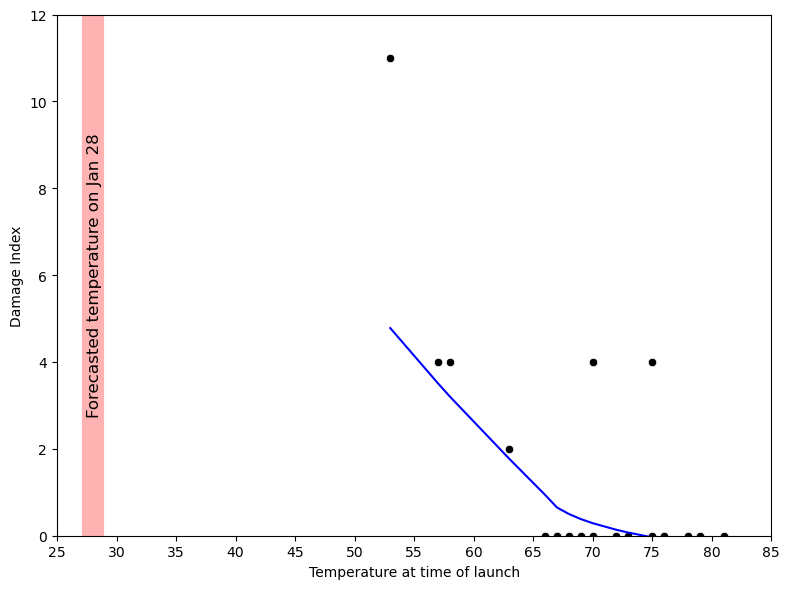

In [3]:
### Figure 4.2

oringDf = pd.read_csv('https://raw.githubusercontent.com/statsthinking21/statsthinking21-figures-data/main/orings.csv', index_col=0)

fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot
sns.scatterplot(
    data=oringDf,
    color='k',
    x="Temperature",
    y="DamageIndex",
    ax=ax
)

# Statsmodels LOESS
loess_fit = sm.nonparametric.lowess(
    endog=oringDf["DamageIndex"],
    exog=oringDf["Temperature"],
    frac=1.0        # span = 1 in ggplot
)

ax.plot(loess_fit[:, 0], loess_fit[:, 1], color="blue")
ax.set_ylim(0, 12)
ax.set_xticks(np.arange(25, 86, 5))
ax.set_xlabel("Temperature at time of launch")
ax.set_ylabel("Damage Index")

# Add annotation text
ax.axvline(
    x=28,
    linewidth=16,
    alpha=0.3,
    color="red"
)
ax.text(
    27.5,
    6,
    "Forecasted temperature on Jan 28",
    rotation=90,
    fontsize=12,
    va="center",
    ha="left"
)

plt.tight_layout()
plt.show()

In [4]:
# Create NHANES adult dataframe
# Load NHANES data
df_NHANES = pd.read_csv('../data/NHANES.csv')

# Drop duplicate IDs
df_NHANES = df_NHANES.drop_duplicates(subset='ID')

df_NHANES_adult = (
    df_NHANES.dropna(subset=["Age", "Height"]).query("Age >= 18")
)

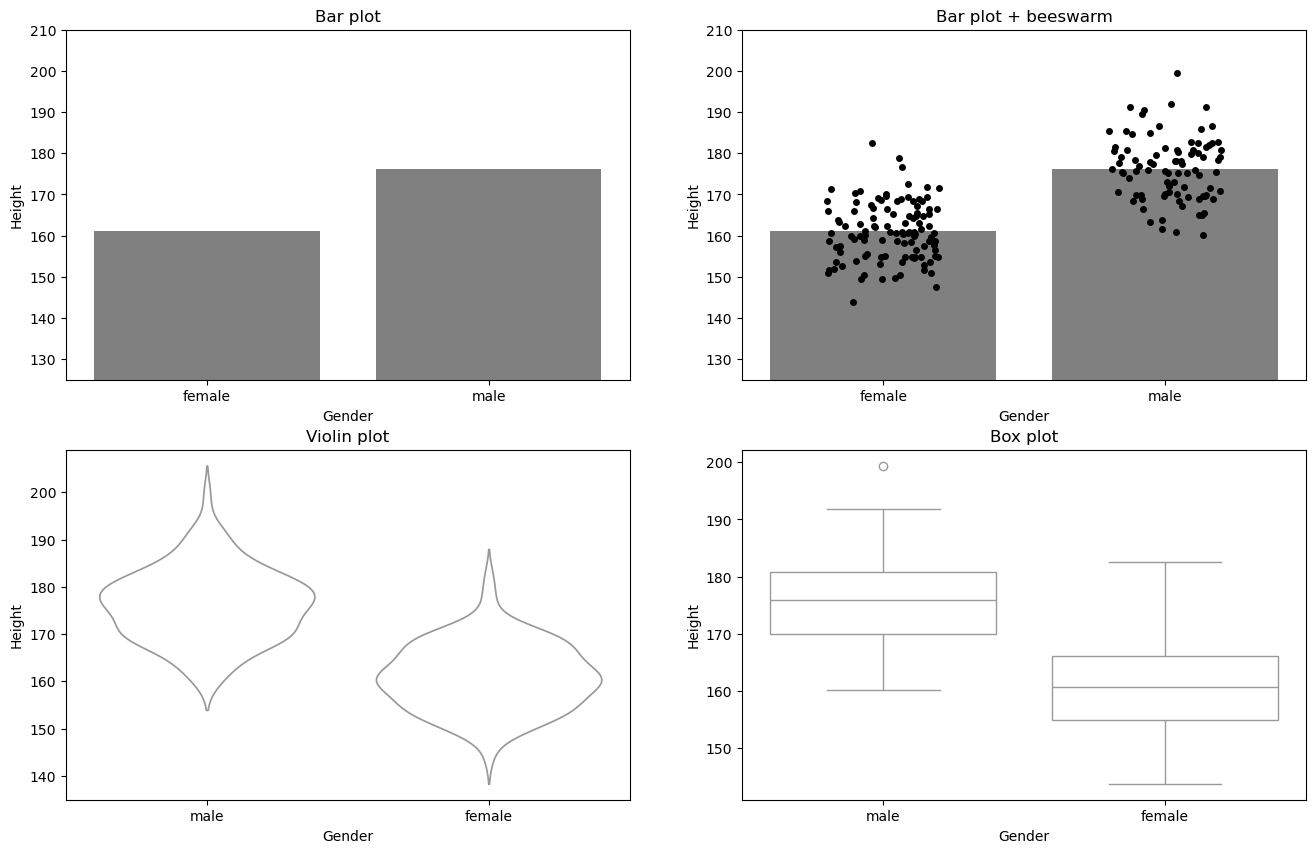

In [24]:
### Figure 4.3

# Sample and group
nhanes_sample = (
    df_NHANES_adult
    .sample(n=200, random_state=12345)
)

dfmean = (
    nhanes_sample
    .groupby("Gender", as_index=False)
    .agg(Height=("Height", "mean"))
)

# Plot 1: Bar plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.barplot(
    data=dfmean,
    x="Gender",
    y="Height",
    ax=axes[0, 0],
    color="gray",
    # edgecolor="black"
)
axes[0, 0].set_ylim(125, 210)
axes[0, 0].set_title("Bar plot")
# axes[0, 0].set_aspect("equal", adjustable="box")

# Plot 2: Bar plot + beeswarm
sns.barplot(
    data=dfmean,
    x="Gender",
    y="Height",
    ax=axes[0, 1],
    color="gray",
    # edgecolor="black"
)

# sns.swarmplot(
#     data=nhanes_sample,
#     x="Gender",
#     y="Height",
#     ax=axes[0, 1],
#     alpha=0.5,
#     size=1.5
# )

sns.stripplot(
    data=nhanes_sample,
    x="Gender",
    y="Height",
    ax=axes[0, 1],
    jitter=0.2,
    color='black',
    size=5
)

axes[0, 1].set_ylim(125, 210)
axes[0, 1].set_title("Bar plot + beeswarm")
# axes[0, 1].set_aspect("equal", adjustable="box")

# Plot 3: Violin plot
sns.violinplot(
    data=nhanes_sample,
    x="Gender",
    y="Height",
    color="white",
    inner=None,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Violin plot")
# axes[1, 0].set_aspect("equal", adjustable="box")

# Plot 4: Box plot
sns.boxplot(
    data=nhanes_sample,
    x="Gender",
    y="Height",
    color="white",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Box plot")
# axes[1, 1].set_aspect("equal", adjustable="box")

# plt.tight_layout()
plt.show()

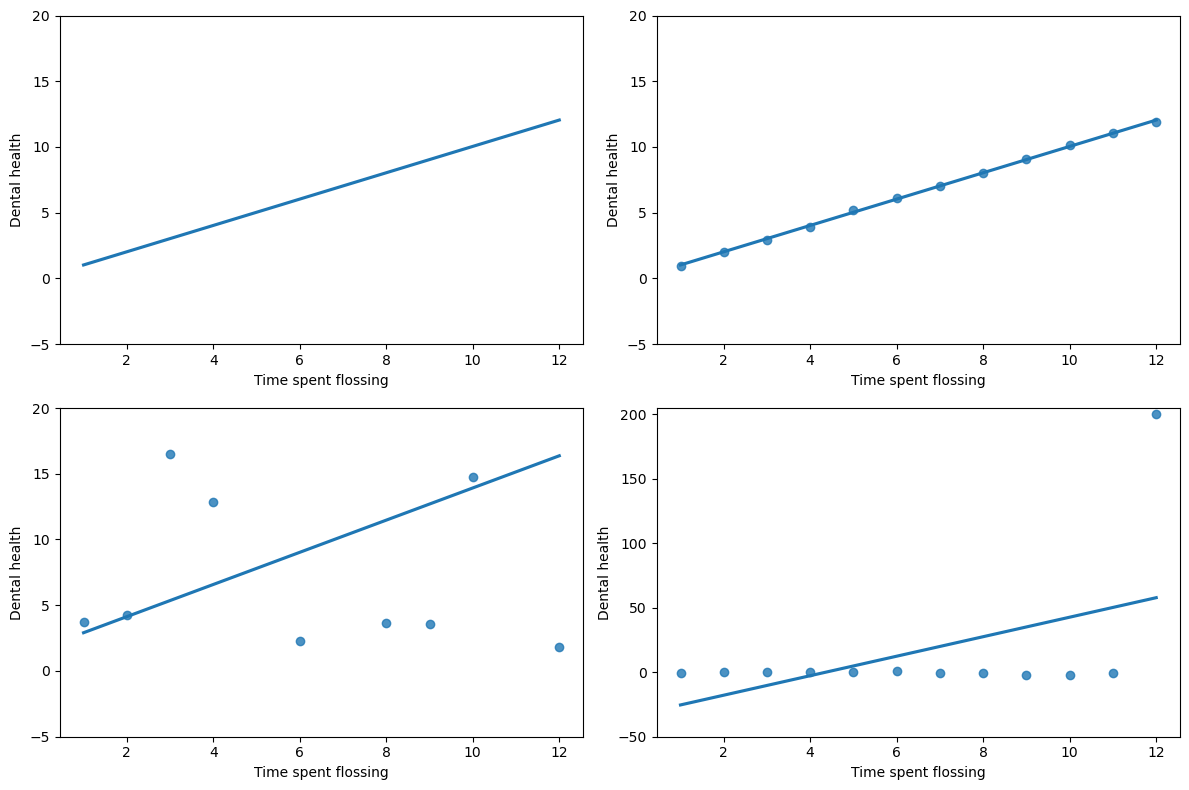

In [25]:
### Figure 4.4

npts = 12
rng = np.random.RandomState(12345)
df = pd.DataFrame({'x': list(range(1, npts + 1))})
df['yClean'] = df.x + rng.randn(npts)*0.1
df['yDirty'] = df.x + rng.randn(npts)*10
df['yOutlier'] = rng.randn(npts)
df.loc[npts - 1, 'yOutlier'] = 200

fig, ax = plt.subplots(2, 2, figsize=(12,8))

sns.regplot(data=df, x='x', y='yClean', ax=ax[0][0], ci=None,scatter=False)

sns.regplot(data=df, x='x', y='yClean', ax=ax[0][1], ci=None)

sns.regplot(data=df, x='x', y='yDirty', ax=ax[1][0], ci=None)

sns.regplot(data=df, x='x', y='yOutlier', ax=ax[1][1], ci=None)

for i in range(2):
    for j in range(2):
        ax[i][j].set_ylim(-5,20)
        ax[i][j].set_ylabel('Dental health')
        ax[i][j].set_xlabel('Time spent flossing')
ax[1][1].set_ylim(-50, 205)
plt.tight_layout()

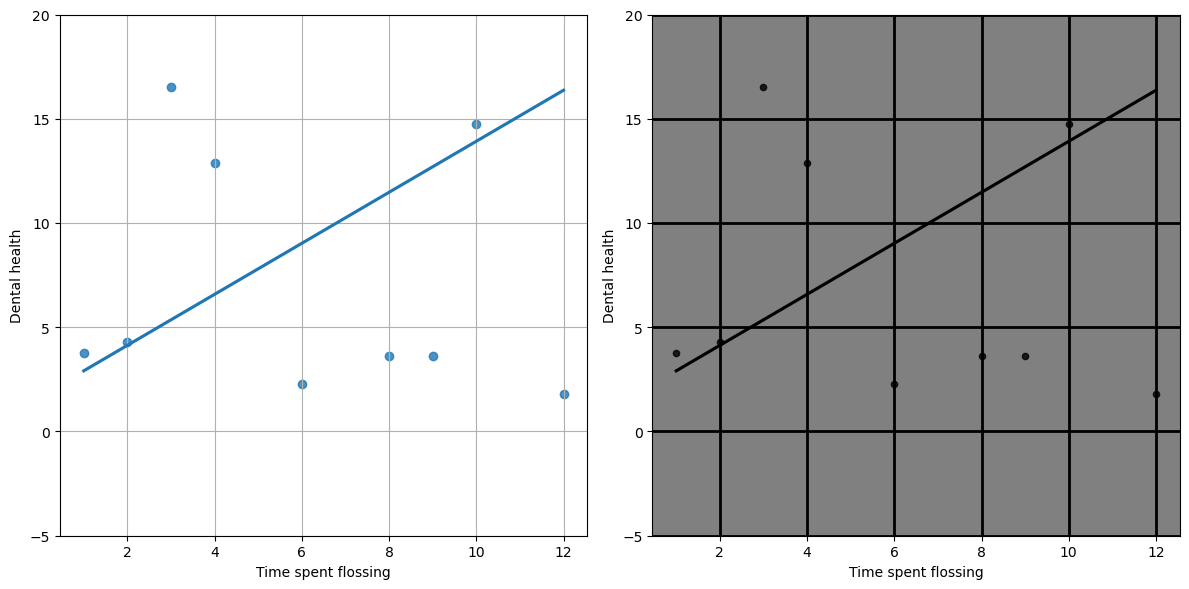

In [31]:
### Figure 4.5

fig, ax = plt.subplots(1, 2, figsize=(12,6))

sns.regplot(data=df, x='x', y='yDirty', ax=ax[0], ci=None)
ax[0].grid()

sns.regplot(data=df, x='x', y='yDirty', ax=ax[1], ci=None, scatter_kws={'s':20}, color ='k')
ax[1].grid(linewidth=2, color='k')
ax[1].set_facecolor('gray')

for i in range(2):
    ax[i].set_ylim(-5,20)
    ax[i].set_ylabel('Dental health')
    ax[i].set_xlabel('Time spent flossing')

plt.tight_layout()

In [ ]:
### Figure 4.7

crimeData = pd.read_csv('https://raw.githubusercontent.com/statsthinking21/statsthinking21-figures-data/main/CrimeStatebyState.csv',  skip_blank_lines=True, comment='#')
crimeData = crimeData.query('Year > 1989')
crimeData['ViolentCrimePerCapita'] = crimeData['Violent crime total'] / crimeData['Population']

fig, ax = plt.subplots(1, 2, figsize=(12,6))

ax[0].plot(crimeData.Year, crimeData.ViolentCrimePerCapita)
ax[0].set_ylim((-0.05,0.05))
ax[1].plot(crimeData.Year, crimeData.ViolentCrimePerCapita)
for i in range(2):
    ax[i].set_xlabel('Year')
    ax[i].set_ylabel('Violent Crime Rate per capita')

plt.tight_layout()